In [ ]:
import os
import scanpy as sc
from muon import prot as pt
from anndata import AnnData
from utils import LoadVisiumCITEseq

/ihome/hosmanbeyoglu/mpekey/.conda/envs/mp_spt/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
data_path = "/ix/hosmanbeyoglu/DATA/Spatial_transriptomics/data"

## Loading and Preprocessing the data

Created 10x Visium data loader pipeline.


/ihome/hosmanbeyoglu/mpekey/.conda/envs/mp_spt/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/ihome/hosmanbeyoglu/mpekey/.conda/envs/mp_spt/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/ihome/hosmanbeyoglu/mpekey/.conda/envs/mp_spt/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/ihome/hosmanbeyoglu/mpekey/spatial_transcriptomics/utils.py:106: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["mt"] = adata.var_names.str.startswith("MT-")


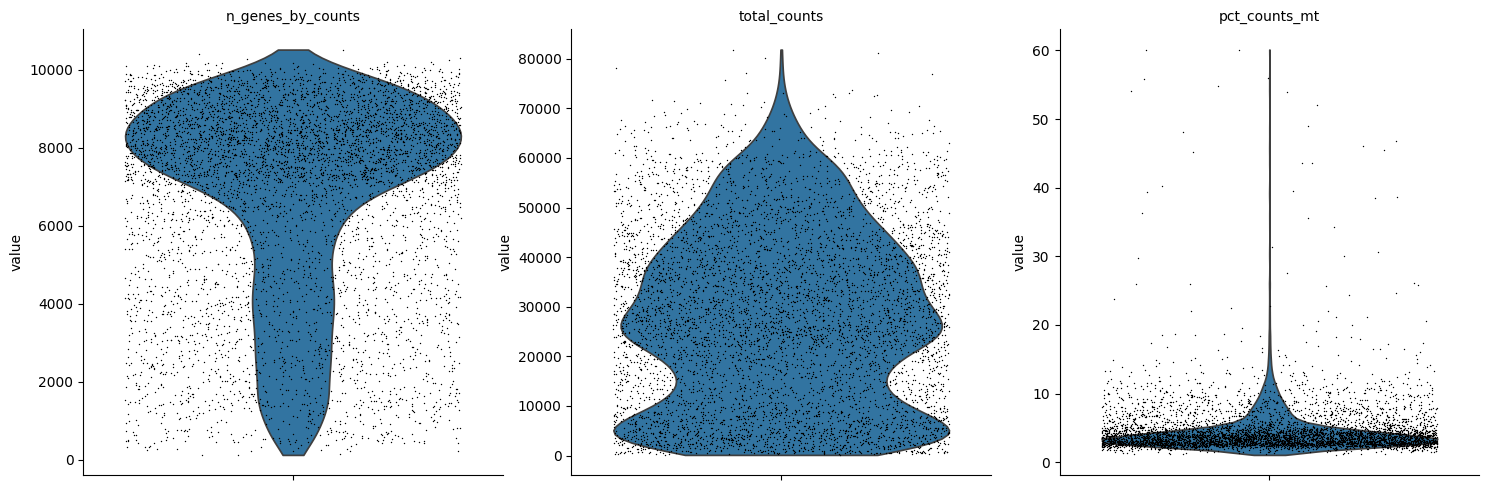

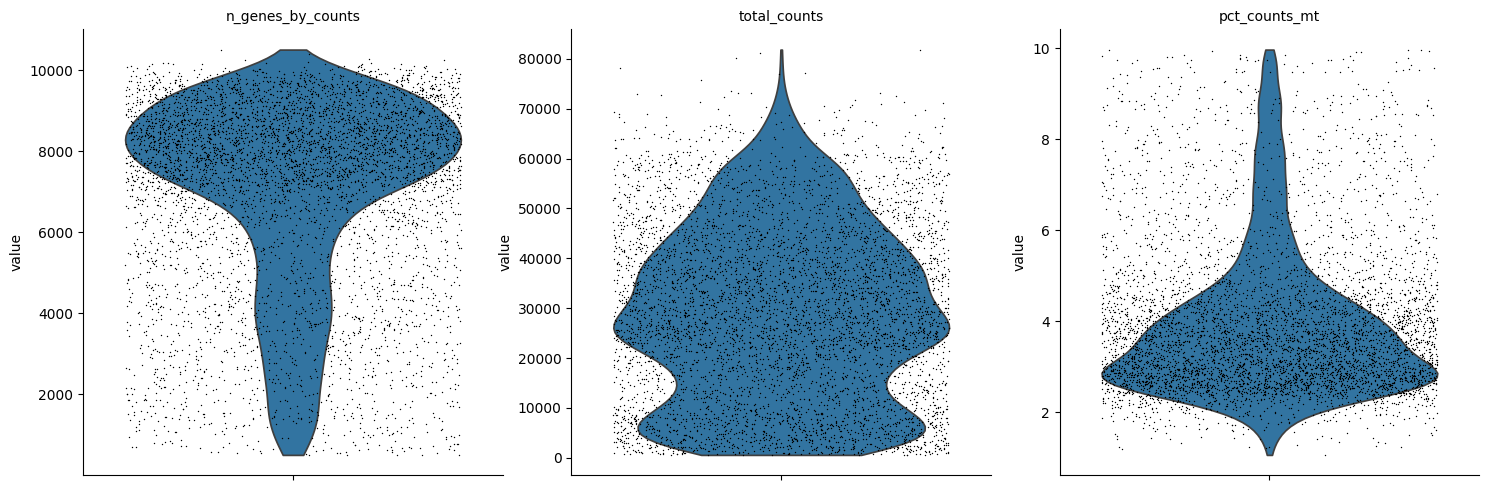

/ihome/hosmanbeyoglu/mpekey/spatial_transcriptomics/utils.py:140: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  self.pdata.var["isotype_control"] = (self.pdata.var_names.str.startswith("mouse_") \
/ihome/hosmanbeyoglu/mpekey/spatial_transcriptomics/utils.py:161: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  self.adata.layers['raw'] = self.adata.X.copy()
/ihome/hosmanbeyoglu/mpekey/spatial_transcriptomics/utils.py:166: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  self.pdata.layers['raw'] = self.pdata.X.copy()
/ihome/hosmanbeyoglu/mpekey/.conda/envs/mp_spt/lib/python3.11/site-packages/muon/_prot/preproc.py:219: UserWarning: adata.X is sparse but not in CSC format. Converting to CSC.
  warn("adata.X is sparse but not in CSC format. Converting to CSC.")


In [ ]:
samples = ["Spatial_CITEseq_Brain", "Spatial_CITEseq_Breast", "Spatial_CITEseq_Tonsil1", "Spatial_CITEseq_Tonsil2"]
adatas = dict()
pdatas = dict()
for sample in samples:
    tissue = sample.split("_")[2]
    if tissue[-1] in ["1", "2"]:
        stissue = tissue[:-1]

    h5_file = f"{data_path}/{sample}/filtered_feature_bc_matrix.h5"

    # initialize loader
    loader = LoadVisiumCITEseq(tissue=tissue, sample_id=sample)

    # load origional raw counts
    loader.load_data(h5_file)

    # filter lower quality cells and genes, option to remove isotype controls
    loader.qc_control(min_n_cells=10, min_n_genes=500, min_pct_genes=1, max_n_genes=None,max_pct_counts_mt=10, remove_isotype=True)

    # normalize data
    loader.normalize(return_raw=False)

    # extract preprocessed mRNA (adata) and protein (pdata)
    (adata, pdata) = loader.get_data()

    # save the data
    adatas[sample] = adata
    pdatas[sample] = pdata


In [ ]:
for sample in samples:

    print(sample)
    print(adatas[sample].shape)
    print(pdatas[sample].shape)


Spatial_CITEseq_Brain
(5449, 17011)
(5449, 31)


### Exploring AnnData

In [ ]:
sample_name = "Spatial_CITEseq_Brain"

In [ ]:
adatas[sample_name]

AnnData object with n_obs × n_vars = 5449 × 17011
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'spatial', 'log1p'
    obsm: 'spatial'
    layers: 'raw', 'norm'

In [ ]:
pdatas[sample_name]

AnnData object with n_obs × n_vars = 5449 × 31
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'raw', 'norm'

**adata - Gene:**
- **n_obs × n_vars:** Number of observations (spots) × Number of variables (genes/proteins).
- **obs:** Metadata about each spot.
- **var:** Metadata about each gene or protein.
- **uns:** Unstructured data, often containing spatial information.
- **obsm:** Contains spatial coordinates for each spot.
- **layers:** Contains both raw and normalized data matrices.

In [ ]:
# obs: Metadata about each spot.
# Type: Pandas Dataframe

print(adatas['Spatial_CITEseq_Brain'].obs.shape)
adatas['Spatial_CITEseq_Brain'].obs.head()

(5449, 12)


,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,n_genes
AACAATGGAACCACAT-1,9742,9.184304,60270.0,11.006606,15.151817,19.160445,24.682263,35.292849,1913.0,7.556951,3.174050,9739
AACACCAGCCTACTCG-1,1297,7.168580,1774.0,7.481556,21.025930,27.113867,38.162345,55.073281,147.0,4.997212,8.286359,1296
AACACCATTCGCATAC-1,8909,9.094930,46474.0,10.746670,16.925593,21.388303,27.258252,38.087963,1514.0,7.323171,3.257735,8908
AACACGCAGATAACAA-1,8372,9.032768,36840.0,10.514367,15.830619,20.295874,26.140065,37.261129,1293.0,7.165493,3.509772,8372
AACACTCGTGAGCTTC-1,5235,8.563313,11790.0,9.375092,14.732824,19.109415,25.148431,37.268872,335.0,5.817111,2.841391,5234


In [ ]:
# var: Metadata about each gene
# Type: Pandas Dataframe

print(adatas['Spatial_CITEseq_Brain'].var.shape)
adatas['Spatial_CITEseq_Brain'].var.head()

(17011, 17)


,gene_ids,feature_types,genome,isotype_control,normalized,pattern,read,secondary_name,sequence,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells
SAMD11,ENSG00000187634,Gene Expression,GRCh38,,FALSE,,,,,False,95,0.016852,0.016712,98.349548,97.0,4.584968,95
NOC2L,ENSG00000188976,Gene Expression,GRCh38,,FALSE,,,,,False,961,0.195101,0.178231,83.304378,1123.0,7.024649,961
KLHL17,ENSG00000187961,Gene Expression,GRCh38,,FALSE,,,,,False,542,0.102328,0.097424,90.583739,589.0,6.380123,542
PLEKHN1,ENSG00000187583,Gene Expression,GRCh38,,FALSE,,,,,False,48,0.008513,0.008477,99.166088,49.0,3.912023,48
PERM1,ENSG00000187642,Gene Expression,GRCh38,,FALSE,,,,,False,15,0.002780,0.002776,99.739402,16.0,2.833213,15


In [ ]:
import matplotlib.pyplot as plt

hires_scalefactor = adatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['scalefactors']['tissue_hires_scalef']
lowres_scalefactor = adatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['scalefactors']['tissue_lowres_scalef']
spatial_coords = adatas['Spatial_CITEseq_Brain'].obsm['spatial'][:3]  # Taking the first 3 coordinates

# Load the high-res image
hires_image = adatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['images']['hires']
lowres_image = adatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['images']['lowres']

# Scale the coordinates to high-res
hires_coords = spatial_coords * hires_scalefactor
lowres_coords = spatial_coords * lowres_scalefactor

print('Spatial Coords:\n', spatial_coords)
print('High Resolution Image Coords:\n', hires_coords)
print('Low Resolution Image Coords:\n', lowres_coords)

Spatial Coords:
 [[23137. 10049.]
 [21933.  3952.]
 [ 6675. 10125.]]
High Resolution Image Coords:
 [[1640.80570352  712.64453104]
 [1555.42168368  280.26382592]
 [ 473.370708    718.03422   ]]
Low Resolution Image Coords:
 [[492.24166478 213.79333921]
 [466.62646124  84.07913987]
 [142.01119905 215.41024575]]


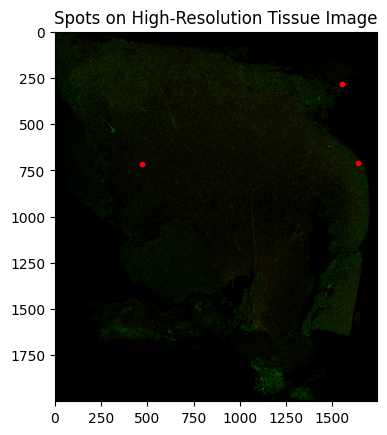

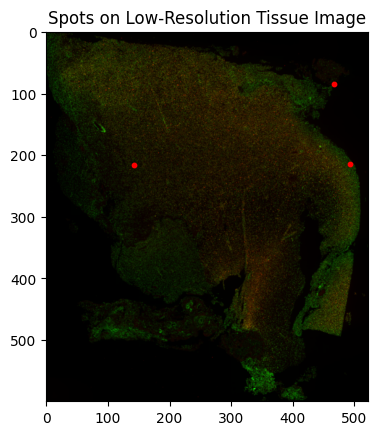

In [ ]:
# Plot the image and overlay the spots
plt.imshow(hires_image)
plt.scatter(hires_coords[:, 0], hires_coords[:, 1], c='red', s=10)  # Adjust 's' to change the spot size
plt.title("Spots on High-Resolution Tissue Image")
plt.show()

plt.imshow(lowres_image)
plt.scatter(lowres_coords[:, 0], lowres_coords[:, 1], c='red', s=10)  # Adjust 's' to change the spot size
plt.title("Spots on Low-Resolution Tissue Image")
plt.show()

In [ ]:
# uns: Unstructured data, often containing spatial information.
# Type: OrderedDict
print(adatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma'].keys())

print('\n--- Analyze images ---')
print('Keys: ', adatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['images'].keys())

print('Image Type: ', type(adatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['images']['hires']))
print('High Res Image Shape: ', adatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['images']['hires'].shape)
print('Low Res Image Shape: ', adatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['images']['lowres'].shape)

######################

print('\n--- Analyze scalefactors ---')
print(adatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['scalefactors'])

######################

print('\n--- Analyze metadata ---')
print(adatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['metadata'])

dict_keys(['images', 'scalefactors', 'metadata'])

--- Analyze images ---
Keys:  dict_keys(['hires', 'lowres'])
Image Type:  <class 'numpy.ndarray'>
High Res Image Shape:  (2000, 1744, 3)
Low Res Image Shape:  (600, 523, 3)

--- Analyze scalefactors ---
{'regist_target_img_scalef': 0.21275087, 'tissue_hires_scalef': 0.07091696, 'tissue_lowres_scalef': 0.021275086, 'fiducial_diameter_fullres': 323.0392526606444, 'spot_diameter_fullres': 184.59385462814916}

--- Analyze metadata ---
{'chemistry_description': 'Visium V5 Slide', 'software_version': 'spaceranger-2.1.0'}


In [ ]:
# obsm: Contains spatial coordinates for each spot.
# Type: AxisArrays
print(adatas['Spatial_CITEseq_Brain'].obsm)

print('Type: ', type(adatas['Spatial_CITEseq_Brain'].obsm['spatial']))

print('Shape: ', adatas['Spatial_CITEseq_Brain'].obsm['spatial'].shape)
print('Example Rows: ', adatas['Spatial_CITEseq_Brain'].obsm['spatial'][:3])

AxisArrays with keys: spatial
Type:  <class 'numpy.ndarray'>
Shape:  (5449, 2)
Example Rows:  [[23137. 10049.]
 [21933.  3952.]
 [ 6675. 10125.]]


In [ ]:
# layers: Contains both raw and normalized data matrices.
# Type: Layers (anndata)
print(type(adatas['Spatial_CITEseq_Brain'].layers['raw'])) # scipy.sparse._csr.csr_matrix
print(type(adatas['Spatial_CITEseq_Brain'].layers['norm'])) # scipy.sparse._csr.csr_matrix

print(adatas['Spatial_CITEseq_Brain'].layers['raw'].shape)
print(adatas['Spatial_CITEseq_Brain'].layers['norm'].shape)

print(adatas['Spatial_CITEseq_Brain'].layers['norm'][0, :10])

<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>
(5449, 17011)
(5449, 17011)
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 3 stored elements and shape (1, 10)>
  Coords	Values
  (0, 1)	0.38407102227211
  (0, 6)	0.6608818769454956
  (0, 7)	1.0553562641143799


In [ ]:
# adatas['Spatial_CITEseq_Brain'].X is same as adatas['Spatial_CITEseq_Brain'].layers['norm']

**pdata - Protein:**

In [ ]:
pdatas['Spatial_CITEseq_Brain']

AnnData object with n_obs × n_vars = 5449 × 31
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'raw', 'norm'

In [ ]:
# var: Metadata about each protein.
# Type: Pandas Dataframe

print(pdatas['Spatial_CITEseq_Brain'].var.shape)
pdatas['Spatial_CITEseq_Brain'].var.head()

(31, 9)


,gene_ids,feature_types,genome,isotype_control,normalized,pattern,read,secondary_name,sequence
CD163-1,CD163,Antibody Capture,,False,TRUE,^(BC),R2,CD163,CGCACCTCATTGTAT
CR2-1,CR2,Antibody Capture,,False,TRUE,^(BC),R2,CD21,AACCTAGTAGTTCGG
PCNA-1,PCNA,Antibody Capture,,False,TRUE,^(BC),R2,PCNA,CATATCTCTCACTCG
VIM-1,VIM,Antibody Capture,,False,TRUE,^(BC),R2,VIM,ACTGGGCAATCACGT
KRT5-1,KRT5,Antibody Capture,,False,TRUE,^(BC),R2,PanCK,AACGTAACAGCGATT


In [ ]:
# uns: Unstructured data, often containing spatial information.
# Type: OrderedDict

print(pdatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma'].keys())

print('\n--- Analyze images ---')
print('Keys: ', pdatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['images'].keys())

print('Image Type: ', type(pdatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['images']['hires']))
print('High Res Image Shape: ', pdatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['images']['hires'].shape)
print('Low Res Image Shape: ', pdatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['images']['lowres'].shape)

######################

print('\n--- Analyze scalefactors ---')
print(pdatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['scalefactors'])

######################

print('\n--- Analyze metadata ---')
print(pdatas['Spatial_CITEseq_Brain'].uns['spatial']['CytAssist_FFPE_Protein_Expression_Human_Glioblastoma']['metadata'])

dict_keys(['images', 'scalefactors', 'metadata'])

--- Analyze images ---
Keys:  dict_keys(['hires', 'lowres'])
Image Type:  <class 'numpy.ndarray'>
High Res Image Shape:  (2000, 1744, 3)
Low Res Image Shape:  (600, 523, 3)

--- Analyze scalefactors ---
{'regist_target_img_scalef': 0.21275087, 'tissue_hires_scalef': 0.07091696, 'tissue_lowres_scalef': 0.021275086, 'fiducial_diameter_fullres': 323.0392526606444, 'spot_diameter_fullres': 184.59385462814916}

--- Analyze metadata ---
{'chemistry_description': 'Visium V5 Slide', 'software_version': 'spaceranger-2.1.0'}


In [ ]:
# obsm: Contains spatial coordinates for each spot.
# Type: AxisArrays
print(pdatas['Spatial_CITEseq_Brain'].obsm)

print('Type: ', type(pdatas['Spatial_CITEseq_Brain'].obsm['spatial']))

print('Shape: ', pdatas['Spatial_CITEseq_Brain'].obsm['spatial'].shape)
print('Example Rows: ', pdatas['Spatial_CITEseq_Brain'].obsm['spatial'][:3])

AxisArrays with keys: spatial
Type:  <class 'numpy.ndarray'>
Shape:  (5449, 2)
Example Rows:  [[23137. 10049.]
 [21933.  3952.]
 [ 6675. 10125.]]


In [ ]:
# layers: Contains both raw and normalized data matrices.
# Type: Layers (anndata)
print(type(pdatas['Spatial_CITEseq_Brain'].layers['raw'])) # scipy.sparse._csr.csr_matrix
print(type(pdatas['Spatial_CITEseq_Brain'].layers['norm'])) # scipy.sparse._csr.csr_matrix

print(pdatas['Spatial_CITEseq_Brain'].layers['raw'].shape)
print(pdatas['Spatial_CITEseq_Brain'].layers['norm'].shape)

print(pdatas['Spatial_CITEseq_Brain'].layers['norm'][0, :10])

<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csc.csc_matrix'>
(5449, 31)
(5449, 31)
<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 10 stored elements and shape (1, 10)>
  Coords	Values
  (0, 0)	1.001198649406433
  (0, 1)	0.6229071021080017
  (0, 2)	0.6429897546768188
  (0, 3)	0.7656372785568237
  (0, 4)	1.693548560142517
  (0, 5)	1.2918781042099
  (0, 6)	0.8350160121917725
  (0, 7)	0.7984917163848877
  (0, 8)	1.4999688863754272
  (0, 9)	0.6306982636451721


In [ ]:
# pdatas['Spatial_CITEseq_Brain'].X is same as pdatas['Spatial_CITEseq_Brain'].layers['norm']